# Task 1 — Logistic Regression

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_score, recall_score
)


### 1. Load Data

I load the provided train and test CSV files and do a quick sanity check (shape, columns, and head).

In [2]:
TRAIN_PATH = "data/adult_train_.csv"
TEST_PATH  = "data/adult_test_.csv"

assert os.path.exists(TRAIN_PATH), f"Train file not found at: {TRAIN_PATH}"
assert os.path.exists(TEST_PATH), f"Test file not found at: {TEST_PATH}"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:", list(train.columns))
print("Test columns:", list(test.columns))

display(train.head())


Train shape: (26048, 14)
Test shape: (6513, 14)

Train columns: ['age', 'workclass', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'label->50K']
Test columns: ['age', 'workclass', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'label->50K']


,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,label->50K
0,33,Local-gov,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,50,United-States,1
1,36,Private,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1887,50,United-States,1
2,58,Self-emp-not-inc,9th,5,Separated,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,0
3,21,Private,Assoc-voc,11,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,46,United-States,0
4,27,Private,Some-college,10,Divorced,Other-service,Not-in-family,White,Male,0,0,40,United-States,0


## (a) Preprocess + Train Logistic Regression (Balanced)

### 2. Handle Missing Values (Step-by-Step)

I first check explicit missing values with `.isnull()`.  
However, the Adult dataset commonly represents missing categorical values using `"?"` (sometimes with whitespace).  
I strip whitespace, count `"?"`, then convert `"?"` to `NaN` so the pipeline can impute properly.


In [3]:
print("Step 1) Explicit missing values (NaN) in TRAIN:")
print(train.isnull().sum())

print("\nStep 1) Explicit missing values (NaN) in TEST:")
print(test.isnull().sum())

# Identify categorical columns robustly (works for object/string dtypes)
categorical_cols = train.select_dtypes(include=["object", "str"]).columns

# Strip whitespace defensively (handles ' ?' etc.)
for df in (train, test):
    for col in categorical_cols:
        df[col] = df[col].astype(str).str.strip()

print("\nStep 2) Hidden missing values represented as '?' in TRAIN:")
for col in categorical_cols:
    cnt = (train[col] == "?").sum()
    if cnt > 0:
        print(f"{col}: {cnt}")

print("\nStep 2) Hidden missing values represented as '?' in TEST:")
for col in categorical_cols:
    cnt = (test[col] == "?").sum()
    if cnt > 0:
        print(f"{col}: {cnt}")

# Convert '?' -> NaN
train = train.replace("?", np.nan)
test  = test.replace("?", np.nan)

print("\nStep 3) Missing values (NaN) in TRAIN after converting '?' -> NaN:")
print(train.isnull().sum())

print("\nStep 3) Missing values (NaN) in TEST after converting '?' -> NaN:")
print(test.isnull().sum())


Step 1) Explicit missing values (NaN) in TRAIN:
age               0
workclass         0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
label->50K        0
dtype: int64

Step 1) Explicit missing values (NaN) in TEST:
age               0
workclass         0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
label->50K        0
dtype: int64

Step 2) Hidden missing values represented as '?' in TRAIN:
workclass: 1447
occupation: 1454
native_country: 458

Step 2) Hidden missing values represented as '?' in TEST:
workclass: 389
occupation: 389
native_country: 125

Step 3) Missing values (NaN) in TRAIN after converting '?' -> NaN:
age                  0
work

### 3. Define Features (X) and Target (y)

I separate predictors from the target label (`label->50K`).

In [4]:
X_train = train.drop(columns=["label->50K"])
y_train = train["label->50K"]

X_test = test.drop(columns=["label->50K"])
y_test = test["label->50K"]

print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "| y_test shape:", y_test.shape)

assert set(y_train.unique()).issubset({0, 1})
assert set(y_test.unique()).issubset({0, 1})


X_train shape: (26048, 13) | y_train shape: (26048,)
X_test shape: (6513, 13) | y_test shape: (6513,)


### 4. Specify Numeric vs Categorical Features

I define which columns are numeric and which are categorical.

#### Note on `capital_gain` and `capital_loss`

Although the instructions list `capital_gain` and `capital_loss` as categorical, the provided CSV contains these fields as integer-valued quantities (e.g., 0, 1887, 2042, 7298). I therefore treat them as numeric features and scale them along with other numeric variables. Treating them as categorical and one-hot encoding would create many sparse columns and would discard the meaningful magnitude information contained in these values.


#### Note on `occupation`

The instructions do not explicitly list `occupation`, but the provided dataset includes this column. I include `occupation` as a categorical predictor because it contains relevant information for income prediction and can improve the model’s ability to learn meaningful patterns.


In [6]:
numeric_features = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

categorical_features = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country",
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical features: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


### 5. Build the Preprocessing Pipeline

- Numeric features: median imputation + scaling  
- Categorical features: most-frequent imputation + one-hot encoding

**Technical note:** I use `StandardScaler(with_mean=False)` because one-hot encoding produces a sparse design matrix.  
This scales by standard deviation **without mean-centering** (which keeps the sparse matrix compatible).

I wrap the preprocessor construction in a `make_preprocessor()` factory function so that each pipeline receives an **independent** object. Passing the same `ColumnTransformer` instance to two pipelines is risky: `Pipeline.fit()` fits transformers in-place, so re-fitting the second pipeline would overwrite the state of the first, which can cause inconsistencies if cells are re-executed out of order.


In [7]:
def make_preprocessor():
    """Return a fresh, unfitted ColumnTransformer each time it is called.
    This ensures each pipeline owns an independent preprocessor instance,
    preventing state from being shared or overwritten across models."""
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )


### 6. Train Logistic Regression with Class Balancing (Task 1a)

Because the dataset is imbalanced, I train Logistic Regression using `class_weight='balanced'` to prioritize the minority class.


In [8]:
model_balanced = Pipeline(steps=[
    ("preprocessor", make_preprocessor()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        solver="lbfgs",
    )),
])

model_balanced.fit(X_train, y_train)

clf_bal = model_balanced.named_steps["classifier"]
print("n_iter_ (balanced):", clf_bal.n_iter_)
print("Balanced model trained.")


n_iter_ (balanced): [196]
Balanced model trained.


### 7. Inspect the Preprocessing Output (After Training)

I inspect how the preprocessing pipeline transforms the data:
- transformed matrix shape
- feature names after one-hot encoding
- a preview of the first few transformed rows


In [9]:
fitted_preprocessor = model_balanced.named_steps["preprocessor"]

X_train_transformed = fitted_preprocessor.transform(X_train)
print("Transformed matrix shape:", X_train_transformed.shape)

fitted_ohe = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = fitted_ohe.get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(cat_feature_names)

print("Total transformed features:", len(all_feature_names))
print("First 20 feature names:", all_feature_names[:20])

X_preview = X_train_transformed[:5]
X_preview_dense = X_preview.toarray() if hasattr(X_preview, "toarray") else X_preview
preview_df = pd.DataFrame(X_preview_dense, columns=all_feature_names)

display(preview_df.head())


Transformed matrix shape: (26048, 104)
Total transformed features: 104
First 20 feature names: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_10th', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th']


,age,education_num,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,2.418886,5.048244,0.0,0.000000,4.054853,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2.638785,4.271591,0.0,4.675166,4.054853,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,4.251376,1.941632,0.0,0.000000,3.243883,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.539291,4.271591,0.0,0.000000,3.730465,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.979089,3.883265,0.0,0.000000,3.243883,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## (b) Interpret the Beta Coefficients (Task 1b)

Logistic regression models the conditional probability:

$$
P(y=1 \mid x) = \sigma(\beta_0 + \beta^T x)
$$

where $y=1$ corresponds to earning more than $50K$.

Equivalently, it models the **log-odds** linearly:

$$
\log \left( \frac{P(y=1 \mid x)}{1 - P(y=1 \mid x)} \right) = \beta_0 + \beta^T x
$$

Each coefficient $\beta_j$ represents the change in **log-odds** per one-unit increase in feature $x_j$ (holding other variables constant).  
The corresponding **odds ratio** is $\exp(\beta_j)$.

For one-hot encoded categorical variables, each dummy coefficient is interpreted **relative to the omitted reference category**.


In [10]:
fitted_preprocessor = model_balanced.named_steps["preprocessor"]
fitted_ohe = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]

cat_feature_names = fitted_ohe.get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(cat_feature_names)

beta_bal = model_balanced.named_steps["classifier"].coef_[0]
assert len(all_feature_names) == len(beta_bal), "Feature names must align with coefficients (balanced)."

coef_df_bal = pd.DataFrame({
    "Feature": all_feature_names,
    "Beta (Coefficient)": beta_bal,
    "Odds Ratio = exp(Beta)": np.exp(beta_bal),
})

top_pos_bal = coef_df_bal.sort_values("Beta (Coefficient)", ascending=False).head(10)
top_neg_bal = coef_df_bal.sort_values("Beta (Coefficient)", ascending=True).head(10)

print("Top 10 features with the largest POSITIVE weights (increase odds of >50K):")
display(top_pos_bal)

print("\nTop 10 features with the largest NEGATIVE weights (decrease odds of >50K):")
display(top_neg_bal)


Top 10 features with the largest POSITIVE weights (increase odds of >50K):


,Feature,Beta (Coefficient),Odds Ratio = exp(Beta)
2,capital_gain,2.267893,9.659030
30,marital_status_Married-AF-spouse,1.663265,5.276509
63,native_country_Cambodia,1.255660,3.510155
31,marital_status_Married-civ-spouse,1.244109,3.469842
84,native_country_Italy,0.879739,2.410271
55,relationship_Wife,0.854989,2.351349
103,native_country_Yugoslavia,0.824328,2.280348
39,occupation_Exec-managerial,0.750843,2.118785
27,education_Prof-school,0.650506,1.916510
23,education_Doctorate,0.650077,1.915689



Top 10 features with the largest NEGATIVE weights (decrease odds of >50K):


,Feature,Beta (Coefficient),Odds Ratio = exp(Beta)
44,occupation_Priv-house-serv,-1.963356,0.140386
61,sex_Female,-1.606080,0.200673
66,native_country_Columbia,-1.585650,0.204815
33,marital_status_Never-married,-1.402542,0.245971
53,relationship_Own-child,-1.371912,0.253622
68,native_country_Dominican-Republic,-1.286299,0.276291
12,workclass_Without-pay,-1.222102,0.294610
34,marital_status_Separated,-1.176352,0.308402
26,education_Preschool,-1.176070,0.308489
40,occupation_Farming-fishing,-1.170983,0.310062


### Example Interpretations

- If `capital_gain` has $\beta = 2.27$, then $\exp(2.27) \approx 9.66$.  
  This means a one-unit increase in the scaled `capital_gain` multiplies the odds of earning >50K by ~9.66, holding other variables constant.

- If `sex_Female` has $\beta = -1.61$, then $\exp(-1.61) \approx 0.20$.  
  This means the odds of earning >50K are ~20% of the baseline category for sex (the omitted reference), holding other variables constant.


### Interpretation of the Most Influential Features

Examining the estimated beta coefficients, certain features exhibit substantially larger magnitudes, indicating stronger influence on the model’s predicted log-odds of earning more than $50K$. The most influential positive feature is `capital_gain`, which has by far the largest coefficient and odds ratio (approximately 9.66). This implies that higher capital gains dramatically increase the odds of belonging to the high-income class. From a real-world perspective, this is economically intuitive: capital gains reflect investment returns and accumulated wealth, both strongly associated with higher income.

Several marital status indicators (e.g., `marital_status_Married-AF-spouse`, `marital_status_Married-civ-spouse`) also have large positive coefficients. This suggests married individuals in this dataset are statistically more likely to earn above $50K relative to the omitted reference category. In labor economics, marriage is often correlated with age, job stability, and accumulated experience, which may help explain this association. Education-related features such as `education_Prof-school` and `education_Doctorate` appear among the strongest positive predictors, aligning with human capital theory: advanced education increases specialization and access to higher-paying roles.

On the negative side, occupations such as `occupation_Priv-house-serv` and `occupation_Farming-fishing` show strongly negative coefficients, consistent with lower wage structures in those sectors. The negative coefficient for `sex_Female` is also notable; it reflects statistical associations present in the dataset and should be interpreted as correlation rather than causation. Overall, these coefficients are economically meaningful, but logistic regression captures correlations in the data, not causal relationships.


## (c) Majority-Class Baseline (Task 1c)

Before evaluating the model’s test performance, I compute a naive baseline.  
If I ignore all features and always predict the **majority class**, the expected accuracy equals the majority-class proportion in the training set.


In [11]:
majority_class = y_test.value_counts().idxmax()
majority_baseline = y_test.value_counts(normalize=True).max()

print(f"Majority class (in test set): {majority_class}")
print(f"Baseline accuracy (majority-class classifier): {majority_baseline:.4f}")

Majority class (in test set): 0
Baseline accuracy (majority-class classifier): 0.7588


## (d) Evaluate Balanced Model on the Test Set (Task 1d)

I now evaluate the balanced logistic regression model on the test set using the required metrics:
- Accuracy
- F1-score
- ROC-AUC

I also print the confusion matrix (rows=true, cols=pred).


In [13]:
y_pred_balanced = model_balanced.predict(X_test)
y_prob_balanced = model_balanced.predict_proba(X_test)[:, 1]

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
roc_auc_balanced = roc_auc_score(y_test, y_prob_balanced)

cm_bal = confusion_matrix(y_test, y_pred_balanced)
print("\nConfusion Matrix (rows=true, cols=pred):\n", cm_bal)

print("\nBalanced Logistic Regression Performance:")
print(f"Accuracy: {accuracy_balanced:.4f}")
print(f"Precision (Class=1): {precision_balanced:.4f}")
print(f"Recall (Class=1): {recall_balanced:.4f}")
print(f"F1-score: {f1_balanced:.4f}")
print(f"ROC-AUC: {roc_auc_balanced:.4f}")

print(f"\nBaseline accuracy (majority-class classifier): {majority_baseline:.4f}")
print(f"Model beats baseline? {accuracy_balanced > majority_baseline}")



Confusion Matrix (rows=true, cols=pred):
 [[3926 1016]
 [ 247 1324]]

Balanced Logistic Regression Performance:
Accuracy: 0.8061
Precision (Class=1): 0.5658
Recall (Class=1): 0.8428
F1-score: 0.6771
ROC-AUC: 0.9073

Baseline accuracy (majority-class classifier): 0.7588
Model beats baseline? True


## (e) Repeat (a)–(d) WITHOUT Class Balancing (Task 1e)

I repeat the same workflow but train Logistic Regression **without** `class_weight='balanced'` and compare results.


In [14]:
model_unbalanced = Pipeline(steps=[
    ("preprocessor", make_preprocessor()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
    )),
])

model_unbalanced.fit(X_train, y_train)

clf_unbal = model_unbalanced.named_steps["classifier"]
print("n_iter_ (unbalanced):", clf_unbal.n_iter_)
print("Unbalanced model trained.")


n_iter_ (unbalanced): [160]
Unbalanced model trained.


### (e) Coefficients (Unbalanced)

I extract the beta coefficients and show the top positive/negative weights for the unbalanced model.


In [15]:
fitted_preprocessor_unbal = model_unbalanced.named_steps["preprocessor"]
fitted_ohe_unbal = fitted_preprocessor_unbal.named_transformers_["cat"].named_steps["onehot"]

cat_feature_names_unbal = fitted_ohe_unbal.get_feature_names_out(categorical_features)
all_feature_names_unbal = list(numeric_features) + list(cat_feature_names_unbal)

beta_unbal = model_unbalanced.named_steps["classifier"].coef_[0]
assert len(all_feature_names_unbal) == len(beta_unbal), "Feature names must align with coefficients (unbalanced)."

coef_df_unbal = pd.DataFrame({
    "Feature": all_feature_names_unbal,
    "Beta (Coefficient)": beta_unbal,
    "Odds Ratio = exp(Beta)": np.exp(beta_unbal),
})

top_pos_unbal = coef_df_unbal.sort_values("Beta (Coefficient)", ascending=False).head(10)
top_neg_unbal = coef_df_unbal.sort_values("Beta (Coefficient)", ascending=True).head(10)

print("Top 10 POSITIVE weights (unbalanced):")
display(top_pos_unbal)

print("\nTop 10 NEGATIVE weights (unbalanced):")
display(top_neg_unbal)


Top 10 POSITIVE weights (unbalanced):


,Feature,Beta (Coefficient),Odds Ratio = exp(Beta)
2,capital_gain,2.205897,9.078389
30,marital_status_Married-AF-spouse,1.374304,3.952325
63,native_country_Cambodia,1.167173,3.212896
31,marital_status_Married-civ-spouse,1.158239,3.184321
84,native_country_Italy,0.917548,2.503146
55,relationship_Wife,0.792902,2.209800
39,occupation_Exec-managerial,0.726118,2.067040
48,occupation_Tech-support,0.646561,1.908965
72,native_country_France,0.635368,1.887717
27,education_Prof-school,0.609803,1.840068



Top 10 NEGATIVE weights (unbalanced):


,Feature,Beta (Coefficient),Odds Ratio = exp(Beta)
44,occupation_Priv-house-serv,-1.681183,0.186154
61,sex_Female,-1.658521,0.190420
66,native_country_Columbia,-1.406449,0.245012
53,relationship_Own-child,-1.393179,0.248285
33,marital_status_Never-married,-1.351078,0.258961
26,education_Preschool,-1.138368,0.320341
40,occupation_Farming-fishing,-1.128239,0.323603
68,native_country_Dominican-Republic,-1.119445,0.326461
34,marital_status_Separated,-1.049565,0.350090
12,workclass_Without-pay,-1.036384,0.354735


### (e) Evaluate Unbalanced Model on the Test Set

I evaluate the unbalanced model using Accuracy, F1-score, and ROC-AUC, then compare it to the baseline.


In [16]:
y_pred_unbalanced = model_unbalanced.predict(X_test)
y_prob_unbalanced = model_unbalanced.predict_proba(X_test)[:, 1]

accuracy_unbalanced = accuracy_score(y_test, y_pred_unbalanced)
precision_unbalanced = precision_score(y_test, y_pred_unbalanced)
recall_unbalanced = recall_score(y_test, y_pred_unbalanced)
f1_unbalanced = f1_score(y_test, y_pred_unbalanced)
roc_auc_unbalanced = roc_auc_score(y_test, y_prob_unbalanced)

cm_unbal = confusion_matrix(y_test, y_pred_unbalanced)
print("\nConfusion Matrix (rows=true, cols=pred):\n", cm_unbal)

print("\nUnbalanced Logistic Regression Performance:")
print(f"Accuracy: {accuracy_unbalanced:.4f}")
print(f"Precision (Class=1): {precision_unbalanced:.4f}")
print(f"Recall (Class=1): {recall_unbalanced:.4f}")
print(f"F1-score: {f1_unbalanced:.4f}")
print(f"ROC-AUC: {roc_auc_unbalanced:.4f}")

print(f"\nBaseline accuracy (majority-class classifier): {majority_baseline:.4f}")
print(f"Unbalanced model beats baseline? {accuracy_unbalanced > majority_baseline}")



Confusion Matrix (rows=true, cols=pred):
 [[4613  329]
 [ 617  954]]

Unbalanced Logistic Regression Performance:
Accuracy: 0.8548
Precision (Class=1): 0.7436
Recall (Class=1): 0.6073
F1-score: 0.6685
ROC-AUC: 0.9071

Baseline accuracy (majority-class classifier): 0.7588
Unbalanced model beats baseline? True


## Final Comparison (Baseline vs Balanced vs Unbalanced)

I summarize performance across the baseline and both models.


In [17]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline (Majority Class)", "Logistic (Balanced)", "Logistic (Unbalanced)"],
    "Accuracy": [majority_baseline, accuracy_balanced, accuracy_unbalanced],
    "Precision (Class=1)": [np.nan, precision_balanced, precision_unbalanced],
    "Recall (Class=1)": [np.nan, recall_balanced, recall_unbalanced],
    "F1-score": [np.nan, f1_balanced, f1_unbalanced],
    "ROC-AUC": [np.nan, roc_auc_balanced, roc_auc_unbalanced],
})

display(comparison_df)

,Model,Accuracy,Precision (Class=1),Recall (Class=1),F1-score,ROC-AUC
0,Baseline (Majority Class),0.758790,NaN,NaN,NaN,NaN
1,Logistic (Balanced),0.806080,0.565812,0.842775,0.677065,0.907307
2,Logistic (Unbalanced),0.854752,0.743570,0.607257,0.668535,0.907144


### Coefficient Shift Due to Class Weighting (Balanced vs Unbalanced)

I compare coefficients from both models by aligning on feature names and ranking by absolute difference:

$$
|\beta_{balanced} - \beta_{unbalanced}|
$$

This highlights which features change the most when class balancing is applied.


In [18]:
coef_compare = (
    coef_df_bal[["Feature", "Beta (Coefficient)"]]
    .rename(columns={"Beta (Coefficient)": "Beta_Balanced"})
    .merge(
        coef_df_unbal[["Feature", "Beta (Coefficient)"]].rename(columns={"Beta (Coefficient)": "Beta_Unbalanced"}),
        on="Feature",
        how="inner"
    )
)

coef_compare["AbsDiff"] = (coef_compare["Beta_Balanced"] - coef_compare["Beta_Unbalanced"]).abs()

print("Top 15 features with the largest coefficient differences (|β_bal - β_unbal|):")
display(coef_compare.sort_values("AbsDiff", ascending=False).head(15))


Top 15 features with the largest coefficient differences (|β_bal - β_unbal|):


,Feature,Beta_Balanced,Beta_Unbalanced,AbsDiff
75,native_country_Guatemala,0.390252,0.066702,0.323550
102,native_country_Vietnam,-0.541944,-0.846254,0.304309
30,marital_status_Married-AF-spouse,1.663265,1.374304,0.288961
44,occupation_Priv-house-serv,-1.963356,-1.681183,0.282173
103,native_country_Yugoslavia,0.824328,0.555218,0.269110
87,native_country_Laos,-0.916330,-0.667091,0.249239
99,native_country_Thailand,-0.024267,0.222627,0.246894
97,native_country_South,-0.556700,-0.784724,0.228024
90,native_country_Outlying-US(Guam-USVI-etc),-0.828611,-0.616625,0.211986
91,native_country_Peru,-0.851674,-0.640783,0.210891


## Visualizations

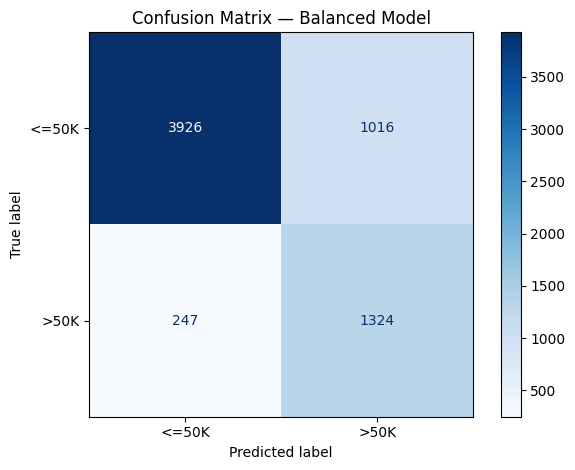

In [21]:
# Confusion Matrix — modelo balanced
cm = confusion_matrix(y_test, y_pred_balanced)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Balanced Model')
plt.tight_layout()
plt.show()

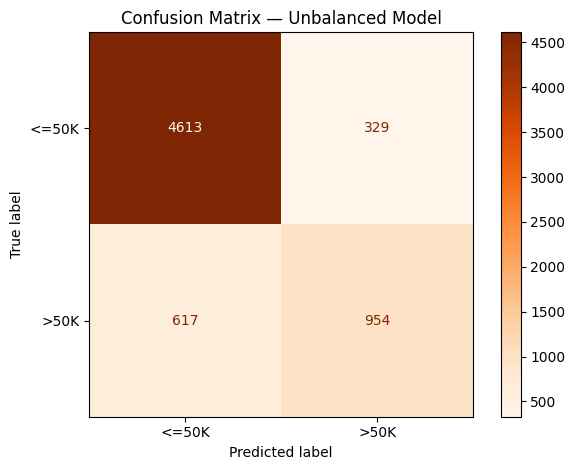

In [23]:
# Confusion Matrix — modelo unbalanced
cm_u = confusion_matrix(y_test, y_pred_unbalanced)
disp_u = ConfusionMatrixDisplay(confusion_matrix=cm_u, display_labels=['<=50K', '>50K'])
disp_u.plot(cmap='Oranges')
plt.title('Confusion Matrix — Unbalanced Model')
plt.tight_layout()
plt.show()

### ROC Curve — Balanced vs Unbalanced

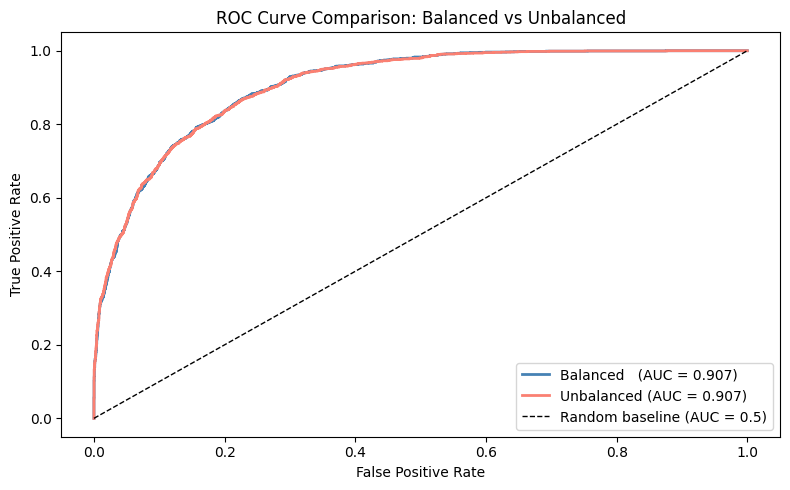

In [22]:
# ROC Curves — balanced vs unbalanced
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_balanced)
fpr_u, tpr_u, _ = roc_curve(y_test, y_prob_unbalanced)

plt.figure(figsize=(8, 5))
plt.plot(fpr_b, tpr_b, color='steelblue', lw=2, label=f'Balanced   (AUC = {roc_auc_balanced:.3f})')
plt.plot(fpr_u, tpr_u, color='salmon',    lw=2, label=f'Unbalanced (AUC = {roc_auc_unbalanced:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Balanced vs Unbalanced')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion (Task 1)

Both logistic regression models outperform the naive majority-class baseline accuracy (~0.759), confirming that the models learn meaningful patterns beyond always predicting the dominant class. The **balanced** model sacrifices overall accuracy but substantially increases **recall** for the minority class (>50K), which is consistent with the purpose of using `class_weight='balanced'` on an imbalanced dataset. The **unbalanced** model achieves higher accuracy largely by better predicting the majority class and improving **precision**, but it misses more minority-class cases (higher false negatives and lower recall). The ROC-AUC values are nearly identical for both models, indicating similar overall ranking/discrimination ability; the key difference is how class weighting shifts the effective decision boundary at the default threshold.
